# IPL Data Analysis

## 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Load Dataset

In [2]:
ipl_df = pd.read_csv("data/matches.csv")
ipl_df.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


## 3. Data Exploratin

In [3]:
ipl_df.shape

(756, 18)

In [4]:
ipl_df.dtypes

id                 int64
season             int64
city                 str
date                 str
team1                str
team2                str
toss_winner          str
toss_decision        str
result               str
dl_applied         int64
winner               str
win_by_runs        int64
win_by_wickets     int64
player_of_match      str
venue                str
umpire1              str
umpire2              str
umpire3              str
dtype: object

In [5]:
ipl_df.isnull().sum()

id                   0
season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               4
win_by_runs          0
win_by_wickets       0
player_of_match      4
venue                0
umpire1              2
umpire2              2
umpire3            637
dtype: int64

In [6]:
ipl_df.duplicated().sum()

np.int64(0)

In [7]:
ipl_df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,756.0,1792.178571,3464.478148,1.0,189.75,378.5,567.25,11415.0
season,756.0,2013.444444,3.366895,2008.0,2011.00,2013.0,2016.00,2019.0
dl_applied,756.0,0.025132,0.156630,0.0,0.00,0.0,0.00,1.0
win_by_runs,756.0,13.283069,23.471144,0.0,0.00,0.0,19.00,146.0
win_by_wickets,756.0,3.350529,3.387963,0.0,0.00,4.0,6.00,10.0


# 4.Data Cleaning

## 4.1 Drop umpire3 column

In [8]:
ipl_df.drop(columns=["umpire3"], inplace=True)
ipl_df.isnull().sum()

id                 0
season             0
city               7
date               0
team1              0
team2              0
toss_winner        0
toss_decision      0
result             0
dl_applied         0
winner             4
win_by_runs        0
win_by_wickets     0
player_of_match    4
venue              0
umpire1            2
umpire2            2
dtype: int64

## 4.2 Check missing winner data

In [9]:
ipl_df[ipl_df["winner"].isna()]

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2
300,301,2011,Delhi,2011-05-21,Delhi Daredevils,Pune Warriors,Delhi Daredevils,bat,no result,0,NaN,0,0,NaN,Feroz Shah Kotla,SS Hazare,RJ Tucker
545,546,2015,Bangalore,2015-04-29,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,no result,0,NaN,0,0,NaN,M Chinnaswamy Stadium,JD Cloete,PG Pathak
570,571,2015,Bangalore,2015-05-17,Delhi Daredevils,Royal Challengers Bangalore,Royal Challengers Bangalore,field,no result,0,NaN,0,0,NaN,M Chinnaswamy Stadium,HDPK Dharmasena,K Srinivasan
744,11340,2019,Bengaluru,30/04/19,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,no result,0,NaN,0,0,NaN,M. Chinnaswamy Stadium,Nigel Llong,Ulhas Gandhe


## 4.3 Check missing player of the match data

In [10]:
ipl_df[ipl_df["player_of_match"].isna()]

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2
300,301,2011,Delhi,2011-05-21,Delhi Daredevils,Pune Warriors,Delhi Daredevils,bat,no result,0,NaN,0,0,NaN,Feroz Shah Kotla,SS Hazare,RJ Tucker
545,546,2015,Bangalore,2015-04-29,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,no result,0,NaN,0,0,NaN,M Chinnaswamy Stadium,JD Cloete,PG Pathak
570,571,2015,Bangalore,2015-05-17,Delhi Daredevils,Royal Challengers Bangalore,Royal Challengers Bangalore,field,no result,0,NaN,0,0,NaN,M Chinnaswamy Stadium,HDPK Dharmasena,K Srinivasan
744,11340,2019,Bengaluru,30/04/19,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,no result,0,NaN,0,0,NaN,M. Chinnaswamy Stadium,Nigel Llong,Ulhas Gandhe


## 4.4 Check missing city data

In [11]:
ipl_df[ipl_df["city"].isna()]

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2
461,462,2014,NaN,2014-04-19,Mumbai Indians,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,7,PA Patel,Dubai International Cricket Stadium,Aleem Dar,AK Chaudhary
462,463,2014,NaN,2014-04-19,Kolkata Knight Riders,Delhi Daredevils,Kolkata Knight Riders,bat,normal,0,Delhi Daredevils,0,4,JP Duminy,Dubai International Cricket Stadium,Aleem Dar,VA Kulkarni
466,467,2014,NaN,2014-04-23,Chennai Super Kings,Rajasthan Royals,Rajasthan Royals,field,normal,0,Chennai Super Kings,7,0,RA Jadeja,Dubai International Cricket Stadium,HDPK Dharmasena,RK Illingworth
468,469,2014,NaN,2014-04-25,Sunrisers Hyderabad,Delhi Daredevils,Sunrisers Hyderabad,bat,normal,0,Sunrisers Hyderabad,4,0,AJ Finch,Dubai International Cricket Stadium,M Erasmus,S Ravi
469,470,2014,NaN,2014-04-25,Mumbai Indians,Chennai Super Kings,Mumbai Indians,bat,normal,0,Chennai Super Kings,0,7,MM Sharma,Dubai International Cricket Stadium,BF Bowden,M Erasmus
474,475,2014,NaN,2014-04-28,Royal Challengers Bangalore,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,5,Sandeep Sharma,Dubai International Cricket Stadium,BF Bowden,S Ravi
476,477,2014,NaN,2014-04-30,Sunrisers Hyderabad,Mumbai Indians,Mumbai Indians,field,normal,0,Sunrisers Hyderabad,15,0,B Kumar,Dubai International Cricket Stadium,HDPK Dharmasena,M Erasmus


In [12]:
ipl_df.loc[ipl_df["city"].isna(), "city"] = "Dubai"

In [13]:
ipl_df["city"].isna().sum()

np.int64(0)

## 4.5 Check missing umpire1 and umpire2 data

In [14]:
ipl_df[ipl_df["umpire1"].isna()]

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN
753,11413,2019,Visakhapatnam,08/05/19,Sunrisers Hyderabad,Delhi Capitals,Delhi Capitals,field,normal,0,Delhi Capitals,0,2,RR Pant,ACA-VDCA Stadium,NaN,NaN


In [15]:
ipl_df[ipl_df["umpire2"].isna()]

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN
753,11413,2019,Visakhapatnam,08/05/19,Sunrisers Hyderabad,Delhi Capitals,Delhi Capitals,field,normal,0,Delhi Capitals,0,2,RR Pant,ACA-VDCA Stadium,NaN,NaN


In [16]:
ipl_df.isnull().sum()

id                 0
season             0
city               0
date               0
team1              0
team2              0
toss_winner        0
toss_decision      0
result             0
dl_applied         0
winner             4
win_by_runs        0
win_by_wickets     0
player_of_match    4
venue              0
umpire1            2
umpire2            2
dtype: int64

# 5. Check Date Type

In [17]:
ipl_df.dtypes

id                 int64
season             int64
city                 str
date                 str
team1                str
team2                str
toss_winner          str
toss_decision        str
result               str
dl_applied         int64
winner               str
win_by_runs        int64
win_by_wickets     int64
player_of_match      str
venue                str
umpire1              str
umpire2              str
dtype: object

In [18]:
ipl_df["date"] = pd.to_datetime(ipl_df["date"], errors="coerce")
ipl_df["date"].dtype

dtype('<M8[us]')

# 6. Check Data Consistency

In [19]:
print(ipl_df["team1"].unique())
print("-----------------------------------------------------------")
print(ipl_df["team2"].unique())
print("-----------------------------------------------------------")
print(ipl_df["winner"].unique())
print("-----------------------------------------------------------")
print(ipl_df["toss_winner"].unique())

<StringArray>
[        'Sunrisers Hyderabad',              'Mumbai Indians',
               'Gujarat Lions',      'Rising Pune Supergiant',
 'Royal Challengers Bangalore',       'Kolkata Knight Riders',
            'Delhi Daredevils',             'Kings XI Punjab',
         'Chennai Super Kings',            'Rajasthan Royals',
             'Deccan Chargers',        'Kochi Tuskers Kerala',
               'Pune Warriors',     'Rising Pune Supergiants',
              'Delhi Capitals']
Length: 15, dtype: str
-----------------------------------------------------------
<StringArray>
['Royal Challengers Bangalore',      'Rising Pune Supergiant',
       'Kolkata Knight Riders',             'Kings XI Punjab',
            'Delhi Daredevils',         'Sunrisers Hyderabad',
              'Mumbai Indians',               'Gujarat Lions',
            'Rajasthan Royals',         'Chennai Super Kings',
             'Deccan Chargers',               'Pune Warriors',
        'Kochi Tuskers Kerala',     'R

In [20]:
replace_data = {
    "Rising Pune Supergiant" : "Rising Pune Supergiants",
    "Delhi Daredevils" : "Delhi Capitals"
}

columns = ["team1", "team2", "winner", "toss_winner"]

for col in columns:
    ipl_df[col] = ipl_df[col].replace(replace_data)
    print(ipl_df[col].unique())

<StringArray>
[        'Sunrisers Hyderabad',              'Mumbai Indians',
               'Gujarat Lions',     'Rising Pune Supergiants',
 'Royal Challengers Bangalore',       'Kolkata Knight Riders',
              'Delhi Capitals',             'Kings XI Punjab',
         'Chennai Super Kings',            'Rajasthan Royals',
             'Deccan Chargers',        'Kochi Tuskers Kerala',
               'Pune Warriors']
Length: 13, dtype: str
<StringArray>
['Royal Challengers Bangalore',     'Rising Pune Supergiants',
       'Kolkata Knight Riders',             'Kings XI Punjab',
              'Delhi Capitals',         'Sunrisers Hyderabad',
              'Mumbai Indians',               'Gujarat Lions',
            'Rajasthan Royals',         'Chennai Super Kings',
             'Deccan Chargers',               'Pune Warriors',
        'Kochi Tuskers Kerala']
Length: 13, dtype: str
<StringArray>
[        'Sunrisers Hyderabad',     'Rising Pune Supergiants',
       'Kolkata Knight Riders

In [21]:
ipl_df["toss_decision"].value_counts()

toss_decision
field    463
bat      293
Name: count, dtype: int64

# 7. Feature Engineering

In [22]:
ipl_df['toss_match_win'] = (ipl_df['toss_winner'] == ipl_df['winner'])
ipl_df['toss_match_win']

0      False
1       True
2       True
3       True
4       True
       ...  
751     True
752    False
753     True
754     True
755     True
Name: toss_match_win, Length: 756, dtype: bool

# 8. Analysis

## 8.1 Most Match winning team

In [23]:
most_winning_teams = ipl_df['winner'].value_counts().reset_index()
most_winning_teams.columns = ['Team', 'Win Count']
most_winning_teams = most_winning_teams.head(10)
most_winning_teams

,Team,Win Count
0,Mumbai Indians,109
1,Chennai Super Kings,100
2,Kolkata Knight Riders,92
3,Royal Challengers Bangalore,84
4,Kings XI Punjab,82
5,Delhi Capitals,77
6,Rajasthan Royals,75
7,Sunrisers Hyderabad,58
8,Deccan Chargers,29
9,Rising Pune Supergiants,15


## 8.2 Highest Win Percentage

In [24]:
total_match_play = ipl_df['team1'].value_counts() + ipl_df['team2'].value_counts()
total_match_play = total_match_play.reset_index()
total_match_play.columns = ['Team', 'Total Match Play']
total_match_play

,Team,Total Match Play
0,Chennai Super Kings,164
1,Deccan Chargers,75
2,Delhi Capitals,177
3,Gujarat Lions,30
4,Kings XI Punjab,176
5,Kochi Tuskers Kerala,14
6,Kolkata Knight Riders,178
7,Mumbai Indians,187
8,Pune Warriors,46
9,Rajasthan Royals,147


In [25]:
team_stats = pd.merge(most_winning_teams, total_match_play, on='Team')

team_stats['win_percentage'] = (team_stats['Win Count'] / team_stats['Total Match Play']) * 100

team_stats['win_percentage'] = team_stats['win_percentage'].round(2)

team_stats.sort_values(by='win_percentage', ascending=False)

team_stats

,Team,Win Count,Total Match Play,win_percentage
0,Mumbai Indians,109,187,58.29
1,Chennai Super Kings,100,164,60.98
2,Kolkata Knight Riders,92,178,51.69
3,Royal Challengers Bangalore,84,180,46.67
4,Kings XI Punjab,82,176,46.59
5,Delhi Capitals,77,177,43.50
6,Rajasthan Royals,75,147,51.02
7,Sunrisers Hyderabad,58,108,53.70
8,Deccan Chargers,29,75,38.67
9,Rising Pune Supergiants,15,30,50.00


## 8.3 Toss Analysis

In [26]:
toss_counts = ipl_df['toss_match_win'].value_counts()
toss_counts.index = ['Won Match', 'Lost Match']
toss_counts

Won Match     393
Lost Match    363
Name: count, dtype: int64

In [27]:
toss_win_match_win_percentage = (ipl_df['toss_match_win'].mean() * 100)
print(f"Toss winners won {toss_win_match_win_percentage:.2f}% of matches")

Toss winners won 51.98% of matches


In [28]:
ipl_df['toss_decision'].value_counts()

toss_decision
field    463
bat      293
Name: count, dtype: int64

In [29]:
toss_decision_analysis = ipl_df.groupby('toss_decision')['toss_match_win'].mean().mul(100).round(2)
toss_decision_analysis

toss_decision
bat      45.73
field    55.94
Name: toss_match_win, dtype: float64

In [30]:
toss_analysis = (
    ipl_df.groupby('toss_decision')['toss_match_win'].agg(
        matches='count',
        toss_winner_wins='sum',
        win_percentage='mean'
    )
)

toss_analysis['win_percentage'] = (
    toss_analysis['win_percentage'] * 100
).round(2)

toss_analysis

,matches,toss_winner_wins,win_percentage
toss_decision,,,
bat,293,134,45.73
field,463,259,55.94


## 8.4 Most POTM Award

In [31]:
top_player = ipl_df['player_of_match'].value_counts().head(10).reset_index()
top_player.columns = ['Player', 'POTM Award']
top_player

,Player,POTM Award
0,CH Gayle,21
1,AB de Villiers,20
2,MS Dhoni,17
3,DA Warner,17
4,RG Sharma,17
5,YK Pathan,16
6,SR Watson,15
7,SK Raina,14
8,G Gambhir,13
9,MEK Hussey,12


## 8.5 Venue Analysis

### 8.5.1 Most IPL Match Hosted Venues

In [32]:
ipl_df['venue'].value_counts().head(10)

venue
Eden Gardens                                  77
M Chinnaswamy Stadium                         73
Wankhede Stadium                              73
Feroz Shah Kotla                              67
Rajiv Gandhi International Stadium, Uppal     56
MA Chidambaram Stadium, Chepauk               49
Sawai Mansingh Stadium                        47
Punjab Cricket Association Stadium, Mohali    35
Maharashtra Cricket Association Stadium       21
Dr DY Patil Sports Academy                    17
Name: count, dtype: int64

### 8.5.2 Top Winning Team per Venue

In [33]:
venue_team_wins = (
    ipl_df.dropna(subset=['winner'])
    .groupby(['venue', 'winner'])
    .size()
    .reset_index(name='wins')
)

venue_team_wins = venue_team_wins.sort_values(
    ['venue', 'wins'],
    ascending=[True, False]
)

top_team_per_venue = venue_team_wins.groupby('venue').first()

top_team_per_venue = top_team_per_venue.sort_values(by='wins', ascending=False).reset_index()
top_team_per_venue.head(10)

,venue,winner,wins
0,Eden Gardens,Kolkata Knight Riders,45
1,Wankhede Stadium,Mumbai Indians,42
2,"MA Chidambaram Stadium, Chepauk",Chennai Super Kings,34
3,M Chinnaswamy Stadium,Royal Challengers Bangalore,34
4,Sawai Mansingh Stadium,Rajasthan Royals,32
5,Feroz Shah Kotla,Delhi Capitals,27
6,"Rajiv Gandhi International Stadium, Uppal",Sunrisers Hyderabad,25
7,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,18
8,"Sardar Patel Stadium, Motera",Rajasthan Royals,7
9,"Punjab Cricket Association IS Bindra Stadium, ...",Kings XI Punjab,7


## 8.6 Season Analysis

### 8.6.1 Win Count For Each Season

In [34]:
season_wins = ipl_df.groupby("season")["winner"].value_counts()

season_wins

season  winner                     
2008    Rajasthan Royals               13
        Kings XI Punjab                10
        Chennai Super Kings             9
        Mumbai Indians                  7
        Delhi Capitals                  7
                                       ..
2019    Kolkata Knight Riders           6
        Kings XI Punjab                 6
        Sunrisers Hyderabad             6
        Rajasthan Royals                5
        Royal Challengers Bangalore     5
Name: count, Length: 100, dtype: int64

### 8.6.2 Top Winnig Team in Each Season

In [35]:
top_team_per_season = (
    season_wins
    .groupby(level=0)
    .head(1)
    .reset_index(name='wins')
)

top_team_per_season

,season,winner,wins
0,2008,Rajasthan Royals,13
1,2009,Delhi Capitals,10
2,2010,Mumbai Indians,11
3,2011,Chennai Super Kings,11
4,2012,Kolkata Knight Riders,12
5,2013,Mumbai Indians,13
6,2014,Kings XI Punjab,12
7,2015,Chennai Super Kings,10
8,2016,Sunrisers Hyderabad,11
9,2017,Mumbai Indians,12


### 8.6.3 Top Player For Each Season

In [36]:
top_player_per_season = (ipl_df.groupby('season')['player_of_match'].value_counts()
                         .groupby(level=0)
                         .head(1)
                         .reset_index()
)

top_player_per_season

,season,player_of_match,count
0,2008,SE Marsh,5
1,2009,YK Pathan,3
2,2010,SR Tendulkar,4
3,2011,CH Gayle,6
4,2012,CH Gayle,5
5,2013,MEK Hussey,5
6,2014,GJ Maxwell,4
7,2015,DA Warner,4
8,2016,V Kohli,5
9,2017,BA Stokes,3


## 8.7 Home vs Away Performance

In [44]:
ipl_df['city'] = ipl_df['city'].replace({
    "Bengaluru" : "Bangalore",
    "Mohali" : "Chandigarh"
})

home_city = {
    "Chennai Super Kings": "Chennai",
    "Deccan Chargers": "Hyderabad",
    "Delhi Capitals": "Delhi",
    "Gujarat Lions": "Rajkot",
    "Kings XI Punjab": "Chandigarh",
    "Kochi Tuskers Kerala": "Kochi",
    "Kolkata Knight Riders": "Kolkata",
    "Mumbai Indians": "Mumbai",
    "Pune Warriors": "Pune",
    "Rajasthan Royals": "Jaipur",
    "Rising Pune Supergiants": "Pune",
    "Royal Challengers Bangalore": "Bangalore",
    "Sunrisers Hyderabad": "Hyderabad",
}

neutral_cities = ["Durban", "Centurion", "Johannesburg", "Cape Town", "Port Elizabeth",
                  "East London", "Kimberley", "Bloemfontein", "Abu Dhabi", "Dubai", "Sharjah"]

matches = ipl_df.dropna(subset=['winner'])
team_matches = pd.concat([
    matches.assign(team=matches['team1']),
    matches.assign(team=matches['team2'])
])

team_matches = team_matches[~team_matches['city'].isin(neutral_cities)]
team_matches['is_home'] = team_matches['team'].map(home_city) == team_matches['city']
team_matches['won'] = team_matches['team'] == team_matches['winner']

home_away = team_matches.groupby(['team', 'is_home'])['won'].agg(['count', 'mean']).unstack()
home_away.columns = ['away_matches', 'home_matches', 'away_win_pct', 'home_win_pct']
home_away[["away_win_pct", "home_win_pct"]] = (home_away[["away_win_pct", "home_win_pct"]] * 100).round(2)
home_away["home_advantage"] = (home_away["home_win_pct"] - home_away["away_win_pct"]).round(2)

home_away = home_away[home_away['home_matches'] >= 30].sort_values('home_advantage', ascending=False)
home_away

,away_matches,home_matches,away_win_pct,home_win_pct,home_advantage
team,,,,,
Rajasthan Royals,80,47,42.50,68.09,25.59
Sunrisers Hyderabad,59,44,44.07,68.18,24.11
Chennai Super Kings,89,56,53.93,71.43,17.50
Kings XI Punjab,101,56,39.60,53.57,13.97
Kolkata Knight Riders,86,74,48.84,60.81,11.97
Royal Challengers Bangalore,83,73,43.37,50.68,7.31
Mumbai Indians,87,82,58.62,64.63,6.01
Delhi Capitals,86,69,39.53,44.93,5.40


# 9. Visualization

## 9.1 Most Winning Team

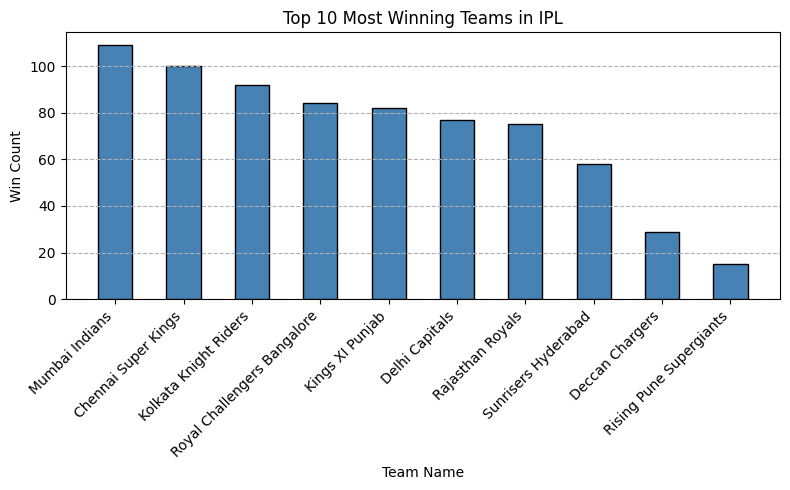

In [37]:
most_winning_teams.columns = ['Team', 'Win Count']

plt.figure(figsize=(8, 5))

plt.bar(most_winning_teams['Team'],
        most_winning_teams['Win Count'],
        color='steelblue',
        edgecolor='black',
        width=0.5)

plt.title('Top 10 Most Winning Teams in IPL')
plt.xlabel('Team Name')
plt.ylabel('Win Count')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.grid(axis='y',
         linestyle='--')

plt.show()

## 9.2 Win Percentage for team

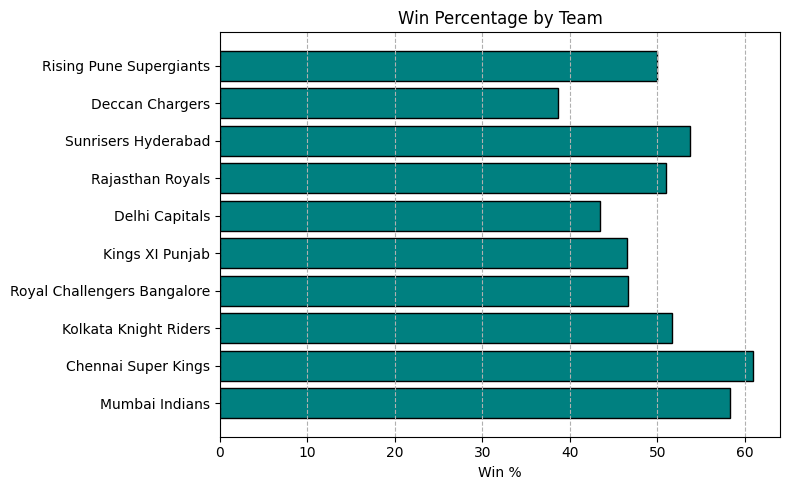

In [38]:
team_stats.columns
plt.figure(figsize=(8, 5))

plt.barh(
    team_stats['Team'],
    team_stats['win_percentage'],
    color='teal',
    edgecolor='black'
)

plt.title('Win Percentage by Team')
plt.xlabel('Win %')

plt.tight_layout()
plt.grid(axis='x', linestyle="--")
plt.show()

## 9.3 Toss Analysis

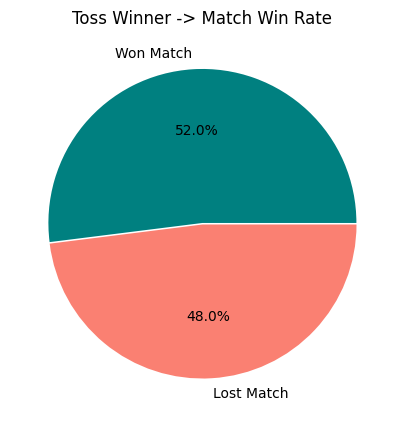

In [39]:
plt.figure(figsize=(8, 5))

plt.pie(toss_counts,
        labels = toss_counts.index,
        colors=['teal', 'salmon'],
        explode=[0.01, 0],
        autopct='%1.1f%%')

plt.title('Toss Winner -> Match Win Rate')

plt.show()


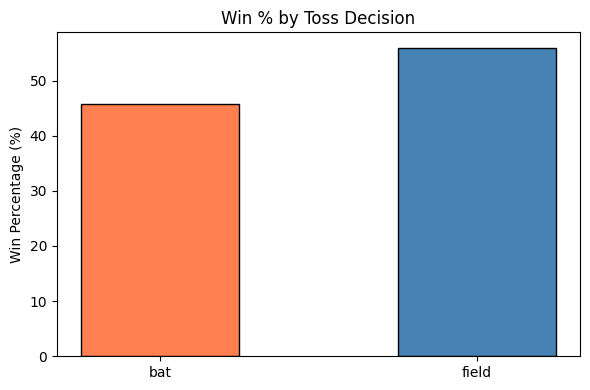

In [40]:
toss_analysis.index
plt.figure(figsize=(6, 4))

plt.bar(
    toss_analysis.index,
    toss_analysis['win_percentage'],
    color=['coral', 'steelblue'],
    edgecolor='black',
    width=0.5
)

plt.title('Win % by Toss Decision')
plt.ylabel('Win Percentage (%)')

plt.tight_layout()
plt.show()



## 9.4 Most POTM Award Winners

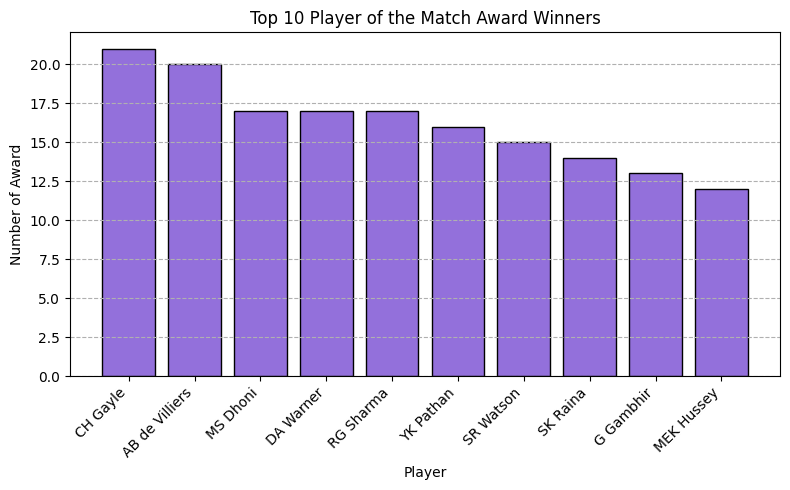

In [43]:
plt.figure(figsize=(8, 5))

plt.bar(top_player['Player'],
        top_player['POTM Award'],
        color='mediumpurple',
        edgecolor='black'
        )

plt.title('Top 10 Player of the Match Award Winners')
plt.ylabel('Number of Award')
plt.xlabel('Player')

plt.grid(axis='y', linestyle='--')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 9.5 Season Analysis

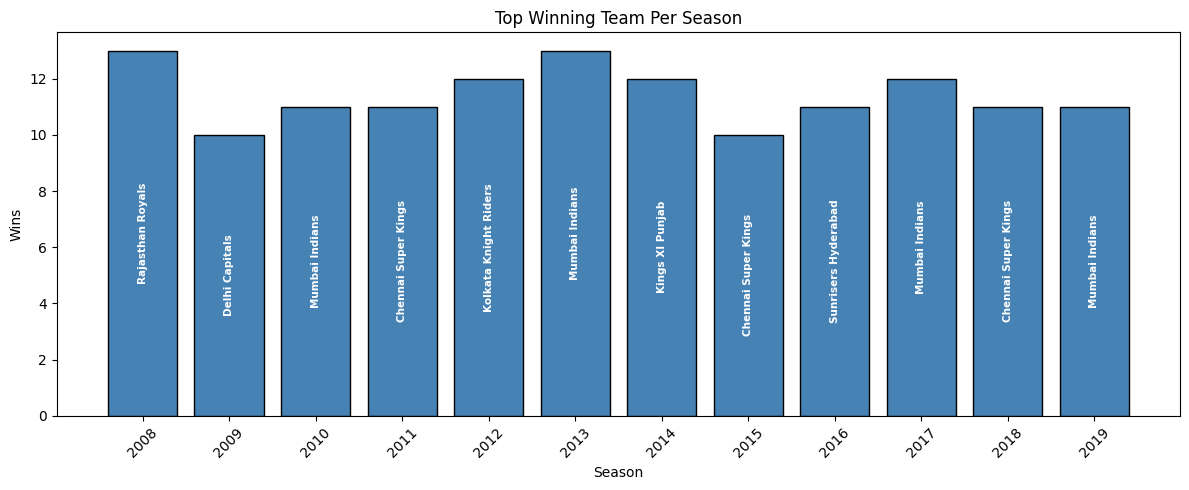

In [42]:
fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(top_team_per_season['season'].astype(str),
              top_team_per_season['wins'],
              color='steelblue',
              edgecolor='black')

for bar, team in zip(bars, top_team_per_season['winner']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() / 2,
            team,
            ha='center',
            va='center',
            fontsize=7.5,
            color='white',
            fontweight='bold',
            rotation=90)
    
ax.set_title('Top Winning Team Per Season')
ax.set_xlabel('Season')
ax.set_ylabel('Wins')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 10. Insights


**Dataset:** 756 IPL matches from 2008 to 2019, covering 13 franchises after merging the renamed teams.

## 10.1 Team Performance
- **Mumbai Indians** have the most wins (109), followed by **Chennai Super Kings** (100) and **Kolkata Knight Riders** (92).
- **Chennai Super Kings** have the best win rate at **60.98%**, ahead of Mumbai Indians (58.29%) and Sunrisers Hyderabad (53.70%). CSK are the most efficient team, while MI win the most because they have played the most matches (187).
- **Deccan Chargers** (38.67%) and **Delhi Capitals** (43.50%) have the lowest win rates among the top 10 winning teams.
- Royal Challengers Bangalore (46.67%) and Kings XI Punjab (46.59%) both win less than half their matches, despite playing a lot of them.

## 10.2 Toss Analysis
- Toss winners won **51.98%** of matches (393 of 756). The toss gives only a small edge.
- Teams chose to **field first in 463 matches (about 61%)** and to bat first in 293.
- Teams that chose to field won **55.94%** of their matches, against **45.73%** for those that chose to bat. Chasing looks like the stronger option in this data.

## 10.3 Player of the Match
- **Chris Gayle (21)** and **AB de Villiers (20)** lead all players.
- MS Dhoni, DA Warner and RG Sharma are tied on 17.
- Gayle was the top award winner in two seasons (6 awards in 2011 and 5 in 2012). No other player tops the table in more than one season.

## 10.4 Venue Analysis
- **Eden Gardens** hosted the most matches (77), followed by M Chinnaswamy Stadium and Wankhede Stadium (73 each).
- Home sides dominate their own grounds:
  - KKR at Eden Gardens: 45 wins
  - MI at Wankhede: 42 wins
  - CSK at Chepauk and RCB at Chinnaswamy: 34 wins each
- Home advantage seems to be a real factor.

## 10.5 Season Trends
- No team led more than twice before 2016.
- **Mumbai Indians** led the win table in 4 seasons (2010, 2013, 2017, 2019), and **Chennai Super Kings** in 3 (2011, 2015, 2018).
- The highest single-season win totals were **13 wins**, by Rajasthan Royals in 2008 and Mumbai Indians in 2013.

## 10.6 Overall Takeaways
1. Mumbai and Chennai are the most successful franchises, in different ways: MI by volume, CSK by win rate.
2. Fielding first is the most popular choice and also the most successful.
3. Home ground advantage is strong, especially at Eden Gardens and Wankhede.
4. Star batters (Gayle, de Villiers, Dhoni, Warner, Rohit) account for most Player of the Match awards.

## 10.7 Limitations
- Win percentages cover only the top 10 teams by wins, so Gujarat Lions, Pune Warriors and Kochi Tuskers Kerala are left out.
- "Top team per season" is the team with the most league wins, not the champion.
- 4 matches with no result have no winner or player of the match, and they are excluded from the win counts.
- Teams that were renamed or dissolved (such as Deccan Chargers and Rising Pune Supergiants) played fewer seasons, which affects their totals.